<div style="background:linear-gradient(135deg,#512E5F 0%,#7D3C98 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#D7BDE2;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 4 · CLASE 10</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">Ejercicios: PCA y SVD</h1>
  <p style="color:#D7BDE2;font-size:16px;margin:0 0 24px 0;font-style:italic;">Eigendecomposición · Scree plot · Biplot · Decorrelación</p>
  <hr style="border-color:#A569BD;margin:0 0 20px 0;">
  <p style="color:#F5EEF8;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; 🟢 Básico · 🟡 Intermedio · 🔴 Avanzado</p>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
np.set_printoptions(precision=4,suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
SEED=42; np.random.seed(SEED)
print('✅ Setup listo')

✅ Setup listo


---
## 🟢 Ejercicio 1 — PCA manual vs sklearn

1. Centrar X y calcular Σ̂
2. Eigendecomposición de Σ̂ (ordenar de mayor a menor)
3. Comparar varianzas con sklearn PCA
4. Proyectar X en las primeras 2 PCs y graficar
5. Verificar que la proyección manual == sklearn transform

In [2]:
np.random.seed(SEED)
n_e1, p_e1 = 150, 4
# Datos con varianzas muy distintas (PCA tiene mucho que hacer)
X_e1 = np.random.randn(n_e1, p_e1) @ np.diag([3.0, 2.0, 1.0, 0.3])
# --- Tu código aquí ---

Varianzas manual:   [7.5946 3.6204 1.0766 0.0853]
Varianzas sklearn:  [7.5946 3.6204 1.0766 0.0853]
Coinciden: True
Proyecciones iguales (módulo signo): True


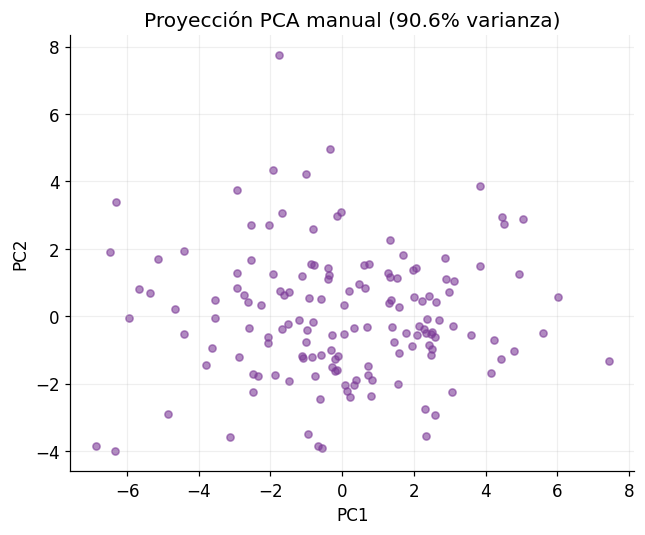


% varianza PC1+PC2: 90.61%


In [3]:
# ✅ SOLUCIÓN
np.random.seed(SEED)
n_e1,p_e1=150,4
X_e1=np.random.randn(n_e1,p_e1)@np.diag([3.0,2.0,1.0,0.3])

# Manual
Xc1=X_e1-X_e1.mean(0); Sigma1=Xc1.T@Xc1/(n_e1-1)
ev1,V1=np.linalg.eigh(Sigma1)
idx1=np.argsort(ev1)[::-1]; ev1=ev1[idx1]; V1=V1[:,idx1]
X_proj_manual=Xc1@V1[:,:2]

# sklearn
pca_e1=PCA(); pca_e1.fit(X_e1)
X_proj_sk=pca_e1.transform(X_e1)[:,:2]

print('Varianzas manual:  ',ev1.round(4))
print('Varianzas sklearn: ',pca_e1.explained_variance_.round(4))
print(f'Coinciden: {np.allclose(ev1,pca_e1.explained_variance_,rtol=0.01)}')

# Las proyecciones pueden diferir en signo
similar=np.allclose(np.abs(X_proj_manual),np.abs(X_proj_sk),atol=1e-8)
print(f'Proyecciones iguales (módulo signo): {similar}')

fig,ax=plt.subplots(figsize=(6,5))
ax.scatter(X_proj_manual[:,0],X_proj_manual[:,1],alpha=0.6,s=22,color='#7D3C98')
ax.set(xlabel='PC1',ylabel='PC2',title=f'Proyección PCA manual ({ev1[:2].sum()/ev1.sum():.1%} varianza)')
ax.grid(True,alpha=0.2); plt.tight_layout(); plt.show()
print(f'\n% varianza PC1+PC2: {pca_e1.explained_variance_ratio_[:2].sum():.2%}')

---
## 🟢 Ejercicio 2 — Scree plot e interpretación

1. Calcular varianza explicada y acumulada
2. Graficar scree plot con barras + línea de varianza acumulada
3. Marcar umbrales 80% y 95%
4. ¿En qué PC está el 'codo'? ¿Cuántas PCs retenerías?

In [4]:
np.random.seed(SEED)
n_e2, p_e2 = 200, 8
# Señal real en primeras 3 dimensiones
X_e2 = (np.random.randn(n_e2, 3) @ np.random.randn(3, p_e2)
        + np.random.randn(n_e2, p_e2) * 0.4)
# --- Tu código aquí ---

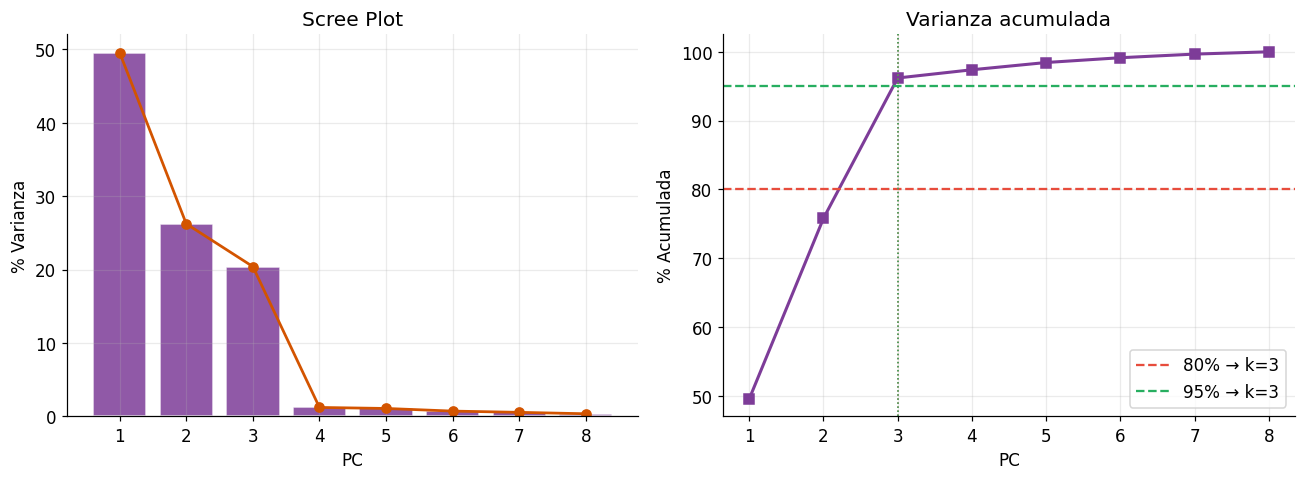

80% varianza: k=3 | 95% varianza: k=3
Codo visual: k≈3 (señal real en 3 dims)
Retendría k=3 por el codo y porque captura la mayoría de la señal.


In [5]:
# ✅ SOLUCIÓN
np.random.seed(SEED); n_e2,p_e2=200,8
X_e2=np.random.randn(n_e2,3)@np.random.randn(3,p_e2)+np.random.randn(n_e2,p_e2)*0.4
pca_e2=PCA(); pca_e2.fit(StandardScaler().fit_transform(X_e2))
var_e2=pca_e2.explained_variance_ratio_; cum_e2=np.cumsum(var_e2)
ks=range(1,p_e2+1)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].bar(ks,var_e2*100,color='#7D3C98',alpha=0.85,edgecolor='white')
axes[0].plot(ks,var_e2*100,'o-',color='#D35400',lw=1.8)
axes[0].set(xlabel='PC',ylabel='% Varianza',title='Scree Plot'); axes[0].grid(True,alpha=0.25)
axes[1].plot(ks,cum_e2*100,'s-',color='#7D3C98',lw=2)
for pct,col in [(80,'#E74C3C'),(95,'#27AE60')]:
    k_pct=np.argmax(cum_e2>=pct/100)+1
    axes[1].axhline(pct,color=col,lw=1.5,linestyle='--',label=f'{pct}% → k={k_pct}')
    axes[1].axvline(k_pct,color=col,lw=1,linestyle=':')
axes[1].set(xlabel='PC',ylabel='% Acumulada',title='Varianza acumulada')
axes[1].legend(); axes[1].grid(True,alpha=0.25)
plt.tight_layout(); plt.show()
n80=np.argmax(cum_e2>=0.80)+1; n95=np.argmax(cum_e2>=0.95)+1
print(f'80% varianza: k={n80} | 95% varianza: k={n95}')
print(f'Codo visual: k≈3 (señal real en 3 dims)')
print('Retendría k=3 por el codo y porque captura la mayoría de la señal.')

---
## 🟡 Ejercicio 3 — Biplot con interpretación

1. Ajustar PCA(n_components=2) al dataset
2. Calcular loadings escalados = components_.T * sqrt(explained_variance_)
3. Graficar biplot (puntos + flechas)
4. Identificar qué features son más importantes en PC1 y PC2
5. ¿Qué features están correlacionadas entre sí?

In [6]:
np.random.seed(SEED)
feats_e3=['precio','descuento','trafico','conversion','ticket_prom','retorno']
n_e3=100
# Precio y ticket_prom correlacionados; trafico y conversion correlacionados
X_e3=np.random.randn(n_e3,6)@np.array([
    [2.0, 0.5, 0.0, 0.0, 0.0, 0.0],
    [-1.5,-0.3, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 2.0, 0.8, 0.0, 0.0],
    [0.0, 0.0, 1.5, 1.0, 0.0, 0.0],
    [1.8, 0.4, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.5, 0.5]
])
# --- Tu biplot aquí ---

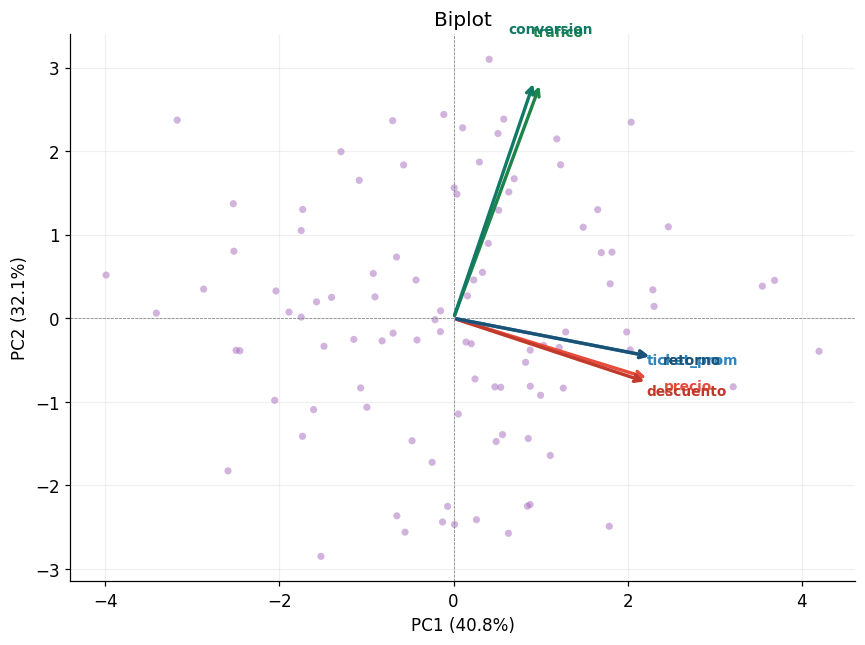

Features importantes en PC1: [(np.float64(0.7611376728752195), 'retorno'), (np.float64(0.7611376728752193), 'ticket_prom'), (np.float64(0.7485688998640186), 'precio'), (np.float64(0.7417863305928758), 'descuento'), (np.float64(0.33308570002827115), 'trafico'), (np.float64(0.3086782585541248), 'conversion')]
Features importantes en PC2: [(np.float64(0.9461867902444151), 'conversion'), (np.float64(0.937763677494368), 'trafico'), (np.float64(0.2559703632098426), 'descuento'), (np.float64(0.24060754811123336), 'precio'), (np.float64(0.15400388520956426), 'retorno'), (np.float64(0.15400388520956423), 'ticket_prom')]


In [7]:
# ✅ SOLUCIÓN
np.random.seed(SEED); feats_e3=['precio','descuento','trafico','conversion','ticket_prom','retorno']
n_e3=100
X_e3=np.random.randn(n_e3,6)@np.array([[2,0.5,0,0,0,0],[-1.5,-0.3,0,0,0,0],[0,0,2,0.8,0,0],[0,0,1.5,1,0,0],[1.8,0.4,0,0,0,0],[0,0,0,0,1.5,0.5]])
X_e3_sc=StandardScaler().fit_transform(X_e3)
pca_e3=PCA(n_components=2); X_e3_proj=pca_e3.fit_transform(X_e3_sc)
loadings_e3=pca_e3.components_.T*np.sqrt(pca_e3.explained_variance_)
fig,ax=plt.subplots(figsize=(8,6))
ax.scatter(X_e3_proj[:,0],X_e3_proj[:,1],alpha=0.5,s=22,color='#A569BD',edgecolors='none')
colores_feat=['#E74C3C','#C0392B','#1E8449','#117A65','#2E86C1','#1A5276']
for i,(feat,col) in enumerate(zip(feats_e3,colores_feat)):
    lx,ly=loadings_e3[i,0]*3,loadings_e3[i,1]*3
    ax.annotate('',xy=(lx,ly),xytext=(0,0),arrowprops=dict(arrowstyle='->',color=col,lw=2.2))
    ax.text(lx*1.2,ly*1.2,feat,fontsize=9,color=col,fontweight='bold',ha='center')
ax.axhline(0,color='gray',lw=0.5,linestyle='--'); ax.axvline(0,color='gray',lw=0.5,linestyle='--')
ax.set(xlabel=f'PC1 ({pca_e3.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca_e3.explained_variance_ratio_[1]:.1%})',title='Biplot')
ax.grid(True,alpha=0.18); plt.tight_layout(); plt.show()
print('Features importantes en PC1:',sorted(zip(np.abs(loadings_e3[:,0]),feats_e3),reverse=True))
print('Features importantes en PC2:',sorted(zip(np.abs(loadings_e3[:,1]),feats_e3),reverse=True))

---
## 🔴 Ejercicio 4 — Pipeline PCA completo

Implementar `pca_summary(X_raw, feature_names)` que:
1. Estandarice y ajuste PCA
2. Imprima varianza por componente y acumulada
3. Recomiende k por criterio 80%, 95% y Kaiser
4. Muestre los top-3 features con mayor loading en PC1
5. Grafique scree + biplot en un solo figure

In [8]:
def pca_summary(X_raw, feature_names):
    pass

np.random.seed(SEED)
n_e4=300; p_e4=7
feats_e4=['ventas','margen','clientes','devolucion','ticket','frecuencia','nps']
X_e4=np.random.randn(n_e4,3)@np.random.randn(3,p_e4)+np.random.randn(n_e4,p_e4)*0.5
pca_summary(X_e4, feats_e4)

═══════════════════════════════════════════════════════
  RESUMEN PCA
═══════════════════════════════════════════════════════
  n=300  p=7
    PC   Varianza   Acumulada        λ
  ─────────────────────────────────────
  PC 1      0.462       0.462    3.245
  PC 2      0.235       0.697    1.650
  PC 3      0.145       0.842    1.017 ←
  PC 4      0.081       0.923    0.572
  PC 5      0.043       0.966    0.301 ←
  PC 6      0.024       0.990    0.166
  PC 7      0.010       1.000    0.071

  Criterio 80%:  k=3
  Criterio 95%:  k=5
  Kaiser (λ>1): k=3

  Top features en PC1: [('clientes', 0.505), ('nps', 0.499), ('margen', 0.485)]
═══════════════════════════════════════════════════════


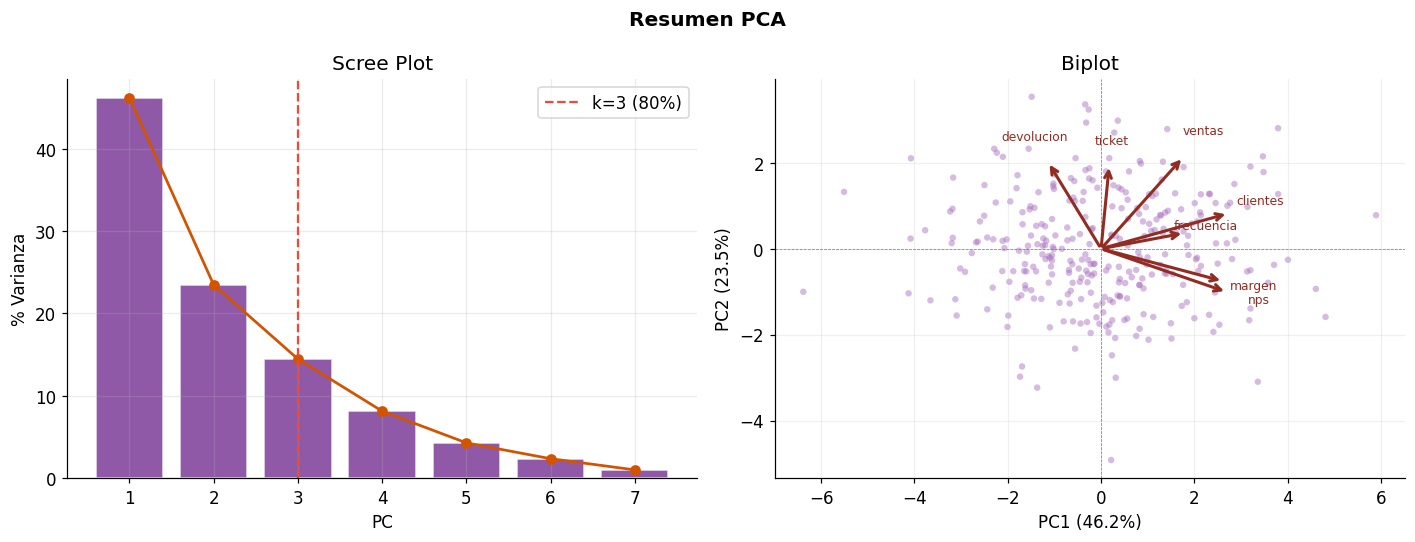

In [9]:
# ✅ SOLUCIÓN
def pca_summary(X_raw,feature_names):
    p=len(feature_names)
    sc=StandardScaler(); Xsc=sc.fit_transform(X_raw)
    pca=PCA(); pca.fit(Xsc)
    var=pca.explained_variance_ratio_; cum=np.cumsum(var); ev=pca.explained_variance_
    print('═'*55); print('  RESUMEN PCA'); print('═'*55)
    print(f'  n={X_raw.shape[0]}  p={p}')
    print(f'  {"PC":>4s} {"Varianza":>10s} {"Acumulada":>11s} {"λ":>8s}')
    print('  '+'─'*37)
    for i,(v,c,e) in enumerate(zip(var,cum,ev)):
        mark=' ←' if c>=0.80 and (i==0 or cum[i-1]<0.80) else (' ←' if c>=0.95 and (i==0 or cum[i-1]<0.95) else '')
        print(f'  PC{i+1:>2d} {v:>10.3f} {c:>11.3f} {e:>8.3f}{mark}')
    k80=np.argmax(cum>=0.80)+1; k95=np.argmax(cum>=0.95)+1; k_kai=int(np.sum(ev>1))
    print(f'\n  Criterio 80%:  k={k80}'); print(f'  Criterio 95%:  k={k95}'); print(f'  Kaiser (λ>1): k={k_kai}')
    # Top features PC1
    load1=np.abs(pca.components_[0])
    top3=np.argsort(load1)[::-1][:3]
    print(f'\n  Top features en PC1: {[(feature_names[i],round(float(pca.components_[0,i]),3)) for i in top3]}')
    print('═'*55)
    # Gráficos
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    ks=range(1,p+1)
    axes[0].bar(ks,var*100,color='#7D3C98',alpha=0.85,edgecolor='white')
    axes[0].plot(ks,var*100,'o-',color='#D35400',lw=1.8)
    axes[0].axvline(k80,color='#E74C3C',lw=1.5,linestyle='--',label=f'k={k80} (80%)')
    axes[0].set(xlabel='PC',ylabel='% Varianza',title='Scree Plot'); axes[0].legend(); axes[0].grid(True,alpha=0.25)
    if p>=2:
        pca2=PCA(n_components=2); Xproj=pca2.fit_transform(Xsc)
        load2=pca2.components_.T*np.sqrt(pca2.explained_variance_)
        axes[1].scatter(Xproj[:,0],Xproj[:,1],alpha=0.45,s=18,color='#A569BD',edgecolors='none')
        for i,feat in enumerate(feature_names):
            lx,ly=load2[i,0]*3,load2[i,1]*3
            axes[1].annotate('',xy=(lx,ly),xytext=(0,0),arrowprops=dict(arrowstyle='->',color='#922B21',lw=2))
            axes[1].text(lx*1.25,ly*1.25,feat,fontsize=8,color='#922B21',ha='center')
        axes[1].axhline(0,color='gray',lw=0.5,linestyle='--'); axes[1].axvline(0,color='gray',lw=0.5,linestyle='--')
        axes[1].set(xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})',ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})',title='Biplot')
        axes[1].grid(True,alpha=0.18)
    plt.suptitle('Resumen PCA',fontweight='bold'); plt.tight_layout(); plt.show()

np.random.seed(SEED); n_e4=300; p_e4=7
feats_e4=['ventas','margen','clientes','devolucion','ticket','frecuencia','nps']
X_e4=np.random.randn(n_e4,3)@np.random.randn(3,p_e4)+np.random.randn(n_e4,p_e4)*0.5
pca_summary(X_e4,feats_e4)

---
<div style="background:#512E5F;color:white;padding:20px 24px;border-radius:8px;">
<strong>Próxima clase — Clase 11</strong><br>
Cuántas PCs retener: Kaiser · Codo · Loadings · Pipeline PCA + clasificación<br>
<em>Docente: Josef Rodriguez · Curso 8 · Módulo 4</em>
</div>